# Tile Labels Analysis

This notebook analyzes mapping fidelity labels from the grid-based tile labeling system.

**Label Categories:**
- Large Overmapping
- Overmapping
- Accurate
- Undermapping
- Large Undermapping

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import seaborn as sns

# Set style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

locations = ['japan', 'porgera', 'lombok']
        # Define colors for each category (matching the app colors)
color_map = {
            'large-overmapping': '#FF0000',
            'overmapping': '#FF8800',
            'accurate': '#00FF00',
            'undermapping': '#0088FF',
            'large-undermapping': '#0000FF'
}

## 1. Load Data

In [66]:
# Path to CSV file
csv_paths = list(map(lambda location: Path(f"../data/{location}/tile_labels_64.csv"), locations))

def load_data(csv_path):
    # Load data
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        print(f"Loaded {len(df)} labeled tiles")
        print(f"\nCSV columns: {df.columns.tolist()}")
        print(f"\nFirst few rows:")
        display(df.head())
    else:
        print(f"CSV file not found at: {csv_path}")
        print("Please check the path or label some tiles first.")
        df = None
    return df

dfs = list(zip(locations, map(load_data, csv_paths)))

Loaded 103 labeled tiles

CSV columns: ['tile_id', 'label', 'confidence', 'notes', 'timestamp']

First few rows:


,tile_id,label,confidence,notes,timestamp
0,tile_51_26,undermapping,medium,NaN,1761705592848
1,tile_25_12,undermapping,medium,NaN,1761705613499
2,tile_73_79,accurate,medium,NaN,1761705633932
3,tile_93_45,accurate,medium,NaN,1761705636582
4,tile_40_85,accurate,medium,NaN,1761705639281


Loaded 116 labeled tiles

CSV columns: ['tile_id', 'label', 'confidence', 'notes', 'timestamp']

First few rows:


,tile_id,label,confidence,notes,timestamp
0,tile_24_33,accurate,medium,NaN,1761715286126
1,tile_39_48,accurate,medium,NaN,1761715288044
2,tile_17_40,undermapping,medium,NaN,1761715291126
3,tile_43_35,accurate,medium,NaN,1761715293225
4,tile_41_43,accurate,medium,NaN,1761715296709


Loaded 102 labeled tiles

CSV columns: ['tile_id', 'label', 'confidence', 'notes', 'timestamp']

First few rows:


,tile_id,label,confidence,notes,timestamp
0,tile_63_100,overmapping,medium,NaN,1761707337499
1,tile_64_113,accurate,medium,NaN,1761707349283
2,tile_17_169,accurate,medium,NaN,1761707358949
3,tile_30_101,undermapping,medium,NaN,1761707364449
4,tile_61_82,overmapping,medium,NaN,1761707368316


## 2. Basic Statistics

In [68]:
def basic_stats(df):
    print(f"Location: {df[0]}")
    df = df[1]
    if df is not None and len(df) > 0:
        # Overall statistics
        print("=" * 60)
        print("OVERALL STATISTICS")
        print("=" * 60)
        print(f"Total labeled tiles: {len(df)}")
        print(f"Unique tiles: {df['tile_id'].nunique()}")
        print(f"Date range: {pd.to_datetime(df['timestamp'], unit='ms').min()} to {pd.to_datetime(df['timestamp'], unit='ms').max()}")
        print()
        
        # Label category counts
        print("=" * 60)
        print("LABEL CATEGORY COUNTS")
        print("=" * 60)
        label_counts = df['label'].value_counts().sort_index()
        print(label_counts)
        print()
        
        # Percentages
        print("=" * 60)
        print("LABEL CATEGORY PERCENTAGES")
        print("=" * 60)
        label_pct = (df['label'].value_counts(normalize=True) * 100).sort_index()
        for label, pct in label_pct.items():
            print(f"{label:25s}: {pct:6.2f}%")
        print()
        
        # Confidence level distribution
        if 'confidence' in df.columns:
            print("=" * 60)
            print("CONFIDENCE LEVEL DISTRIBUTION")
            print("=" * 60)
            confidence_counts = df['confidence'].value_counts()
            print(confidence_counts)
            print()
        
        # Notes statistics
        if 'notes' in df.columns:
            print("=" * 60)
            print("NOTES STATISTICS")
            print("=" * 60)
            notes_filled = df['notes'].notna() & (df['notes'] != '')
            print(f"Tiles with notes: {notes_filled.sum()} ({notes_filled.sum()/len(df)*100:.1f}%)")
            print(f"Tiles without notes: {(~notes_filled).sum()} ({(~notes_filled).sum()/len(df)*100:.1f}%)")
    else:
        print("No data to analyze. Please label some tiles first.")
        
list(map(basic_stats, dfs))

Location: japan
OVERALL STATISTICS
Total labeled tiles: 103
Unique tiles: 103
Date range: 2025-10-29 02:39:52.848000 to 2025-10-29 02:52:47.170000

LABEL CATEGORY COUNTS
label
accurate              60
large-undermapping     4
overmapping           14
undermapping          25
Name: count, dtype: int64

LABEL CATEGORY PERCENTAGES
accurate                 :  58.25%
large-undermapping       :   3.88%
overmapping              :  13.59%
undermapping             :  24.27%

CONFIDENCE LEVEL DISTRIBUTION
confidence
medium    103
Name: count, dtype: int64

NOTES STATISTICS
Tiles with notes: 0 (0.0%)
Tiles without notes: 103 (100.0%)
Location: porgera
OVERALL STATISTICS
Total labeled tiles: 116
Unique tiles: 116
Date range: 2025-10-29 05:21:26.126000 to 2025-10-30 00:20:27.371000

LABEL CATEGORY COUNTS
label
accurate              52
large-overmapping      1
large-undermapping     3
overmapping           14
undermapping          46
Name: count, dtype: int64

LABEL CATEGORY PERCENTAGES
accurate    

[None, None, None]

## 3. Category Counts - Bar Chart

Location: japan


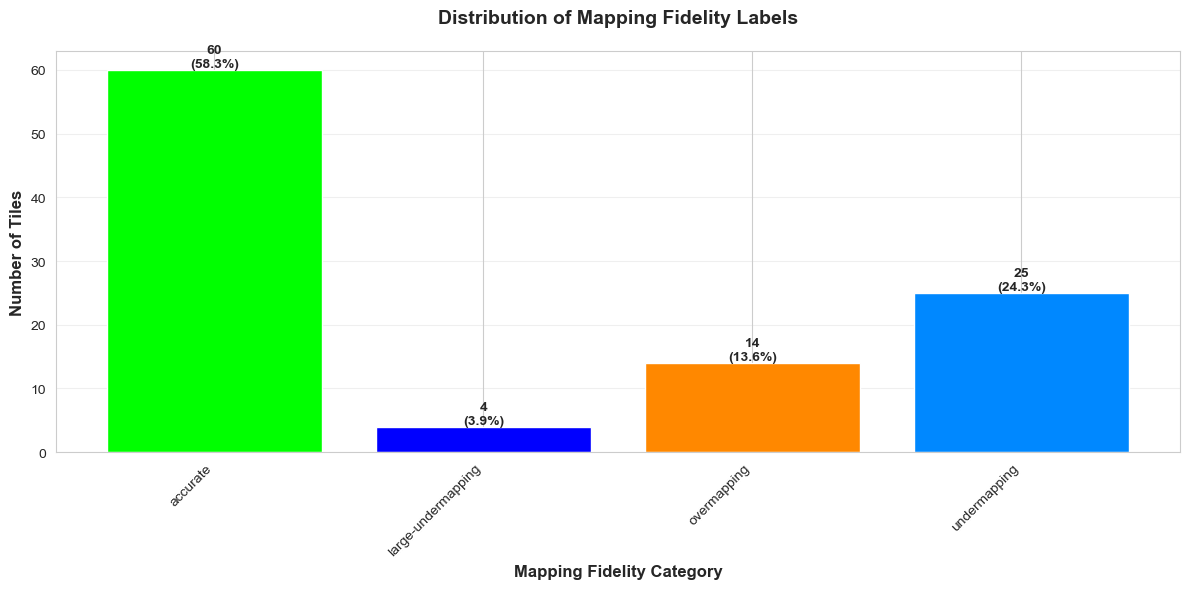

Plot saved to: analysis/label_distribution_bar.png
Location: porgera


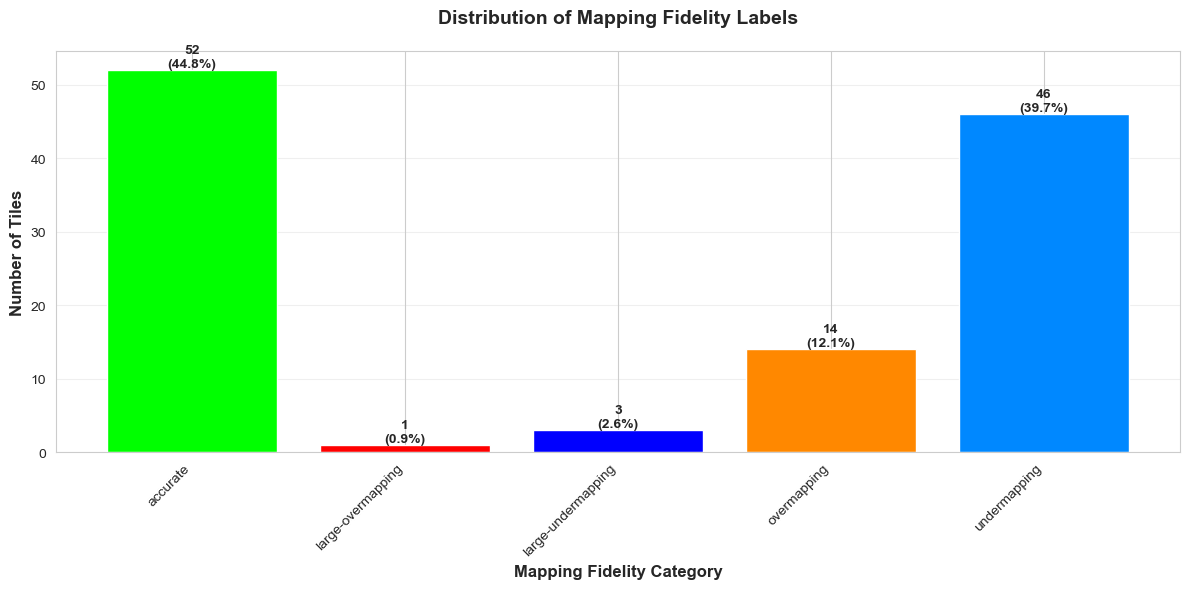

Plot saved to: analysis/label_distribution_bar.png
Location: lombok


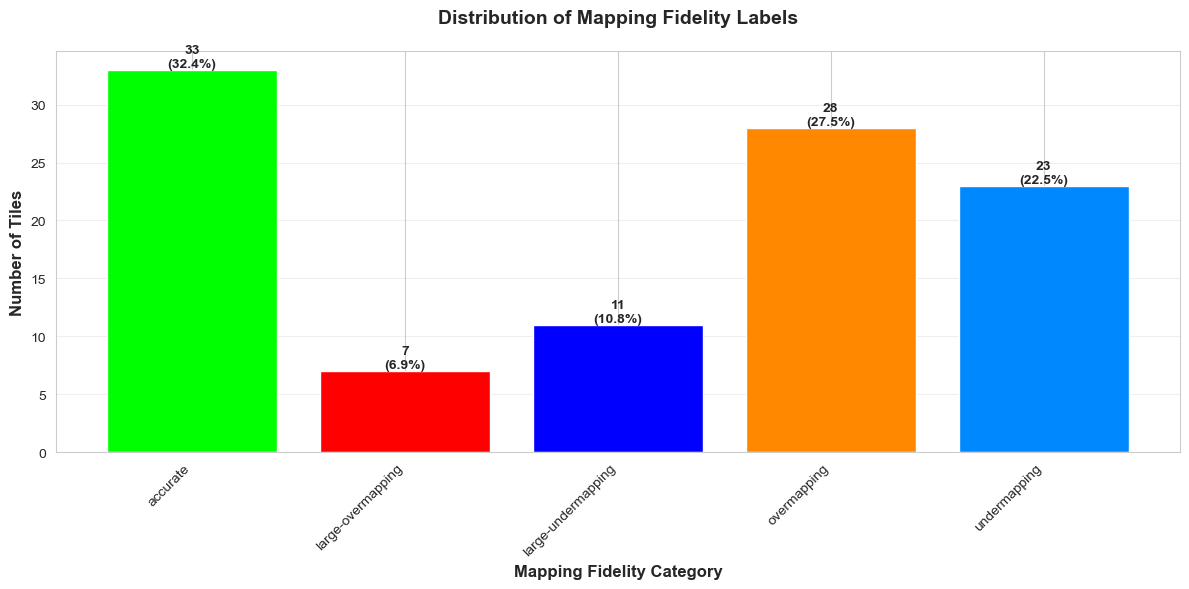

Plot saved to: analysis/label_distribution_bar.png


[None, None, None]

In [70]:
def category_counts(df):
    print(f"Location: {df[0]}")
    df = df[1]
    if df is not None and len(df) > 0:        
        # Get counts
        label_counts = df['label'].value_counts().sort_index()
        
        # Create figure
        fig, ax = plt.subplots(figsize=(12, 6))
        
        # Create bars with custom colors
        bars = ax.bar(range(len(label_counts)), label_counts.values,
                       color=[color_map.get(label, '#808080') for label in label_counts.index])
        
        # Customize plot
        ax.set_xticks(range(len(label_counts)))
        ax.set_xticklabels(label_counts.index, rotation=45, ha='right')
        ax.set_xlabel('Mapping Fidelity Category', fontsize=12, fontweight='bold')
        ax.set_ylabel('Number of Tiles', fontsize=12, fontweight='bold')
        ax.set_title('Distribution of Mapping Fidelity Labels', fontsize=14, fontweight='bold', pad=20)
        
        # Add value labels on bars
        for i, (bar, count) in enumerate(zip(bars, label_counts.values)):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(count)}\n({count/len(df)*100:.1f}%)',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        # Add grid
        ax.yaxis.grid(True, alpha=0.3)
        ax.set_axisbelow(True)
        
        plt.tight_layout()
        plt.savefig('../analysis/label_distribution_bar.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"Plot saved to: analysis/label_distribution_bar.png")
list(map(category_counts, dfs))

## 4. Category Counts - Pie Chart

In [72]:
def category_pies(df):
    if df is not None and len(df) > 0:
        # Get counts
        label_counts = df['label'].value_counts().sort_index()
        
        # Create figure
        fig, ax = plt.subplots(figsize=(10, 8))
        
        # Create pie chart
        colors = [color_map.get(label, '#808080') for label in label_counts.index]
        wedges, texts, autotexts = ax.pie(label_counts.values,
                                            labels=label_counts.index,
                                            colors=colors,
                                            autopct='%1.1f%%',
                                            startangle=90,
                                            textprops={'fontsize': 11, 'fontweight': 'bold'})
        
        # Enhance text visibility
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontsize(12)
        
        ax.set_title('Mapping Fidelity Label Distribution', fontsize=14, fontweight='bold', pad=20)
        
        plt.tight_layout()
        plt.savefig('../analysis/label_distribution_pie.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"Plot saved to: analysis/label_distribution_pie.png")

## 5. Confidence Level Analysis

In [74]:
def confidence_analysis(df):
    if df is not None and len(df) > 0 and 'confidence' in df.columns:
        # Create figure with subplots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        # Overall confidence distribution
        confidence_counts = df['confidence'].value_counts()
        confidence_order = ['low', 'medium', 'high']
        confidence_counts = confidence_counts.reindex([c for c in confidence_order if c in confidence_counts.index])
        
        ax1.bar(range(len(confidence_counts)), confidence_counts.values, 
                color=['#FFC107', '#FF8800', '#00FF00'])
        ax1.set_xticks(range(len(confidence_counts)))
        ax1.set_xticklabels(confidence_counts.index)
        ax1.set_xlabel('Confidence Level', fontsize=11, fontweight='bold')
        ax1.set_ylabel('Number of Tiles', fontsize=11, fontweight='bold')
        ax1.set_title('Overall Confidence Distribution', fontsize=12, fontweight='bold')
        ax1.yaxis.grid(True, alpha=0.3)
        
        # Add value labels
        for i, count in enumerate(confidence_counts.values):
            ax1.text(i, count, f'{int(count)}', ha='center', va='bottom', fontweight='bold')
        
        # Confidence by label category (stacked bar)
        conf_by_label = pd.crosstab(df['label'], df['confidence'])
        conf_by_label = conf_by_label.reindex(columns=[c for c in confidence_order if c in conf_by_label.columns], fill_value=0)
        
        conf_by_label.plot(kind='bar', stacked=True, ax=ax2, 
                           color=['#FFC107', '#FF8800', '#00FF00'])
        ax2.set_xlabel('Label Category', fontsize=11, fontweight='bold')
        ax2.set_ylabel('Number of Tiles', fontsize=11, fontweight='bold')
        ax2.set_title('Confidence by Label Category', fontsize=12, fontweight='bold')
        ax2.legend(title='Confidence', loc='upper right')
        ax2.yaxis.grid(True, alpha=0.3)
        plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        plt.tight_layout()
        plt.savefig('../analysis/confidence_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"Plot saved to: analysis/confidence_analysis.png")
        
        # Print confidence statistics by category
        print("\n" + "=" * 60)
        print("CONFIDENCE BY LABEL CATEGORY")
        print("=" * 60)
        print(conf_by_label)
        print()
        print("Percentages:")
        print((conf_by_label.div(conf_by_label.sum(axis=1), axis=0) * 100).round(1))

## 6. Temporal Analysis

In [76]:
def temporal_analysis(df):
    if df is not None and len(df) > 0 and 'timestamp' in df.columns:
        # Convert timestamp to datetime
        df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms')
        df['date'] = df['datetime'].dt.date
        
        # Labels per day
        labels_per_day = df.groupby('date').size()
        
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(labels_per_day.index, labels_per_day.values, marker='o', linewidth=2, markersize=6)
        ax.fill_between(labels_per_day.index, labels_per_day.values, alpha=0.3)
        ax.set_xlabel('Date', fontsize=11, fontweight='bold')
        ax.set_ylabel('Number of Tiles Labeled', fontsize=11, fontweight='bold')
        ax.set_title('Labeling Activity Over Time', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        plt.xticks(rotation=45, ha='right')
        
        plt.tight_layout()
        plt.savefig('../analysis/temporal_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"Plot saved to: analysis/temporal_analysis.png")
        
        print("\n" + "=" * 60)
        print("LABELING ACTIVITY BY DATE")
        print("=" * 60)
        print(labels_per_day)
        print()
        print(f"Average labels per day: {labels_per_day.mean():.1f}")
        print(f"Most productive day: {labels_per_day.idxmax()} ({labels_per_day.max()} tiles)")

## 7. Overmapping vs Undermapping Analysis

Location: japan
BROAD CATEGORY ANALYSIS
broad_category
Accurate        60
Undermapping    29
Overmapping     14
Name: count, dtype: int64

Accurate       :   60 tiles ( 58.3%)
Undermapping   :   29 tiles ( 28.2%)
Overmapping    :   14 tiles ( 13.6%)


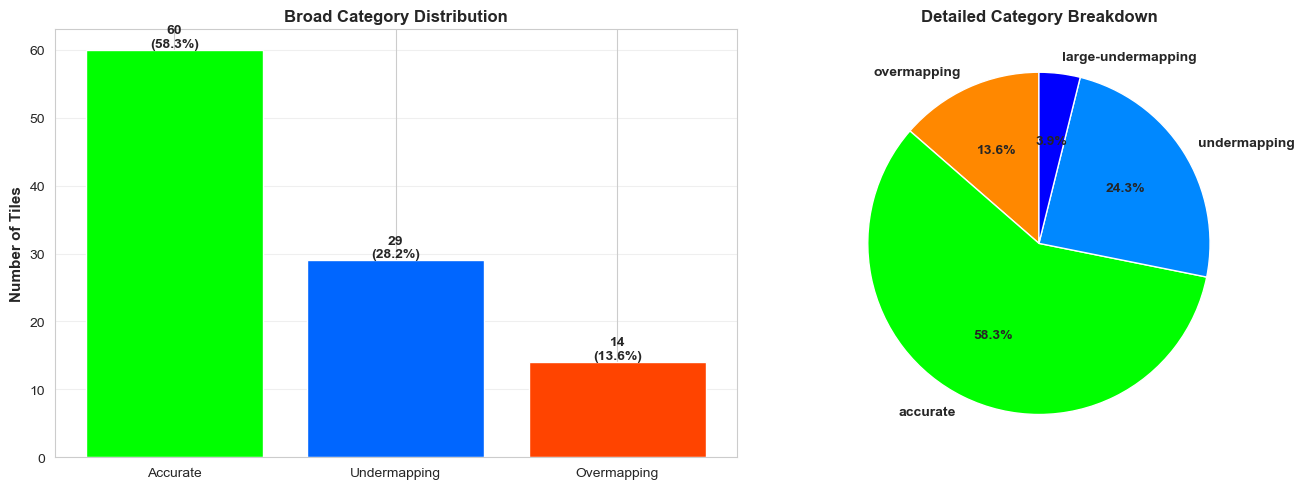


Plot saved to: analysis/broad_category_analysis.png
Location: porgera
BROAD CATEGORY ANALYSIS
broad_category
Accurate        52
Undermapping    49
Overmapping     15
Name: count, dtype: int64

Accurate       :   52 tiles ( 44.8%)
Undermapping   :   49 tiles ( 42.2%)
Overmapping    :   15 tiles ( 12.9%)


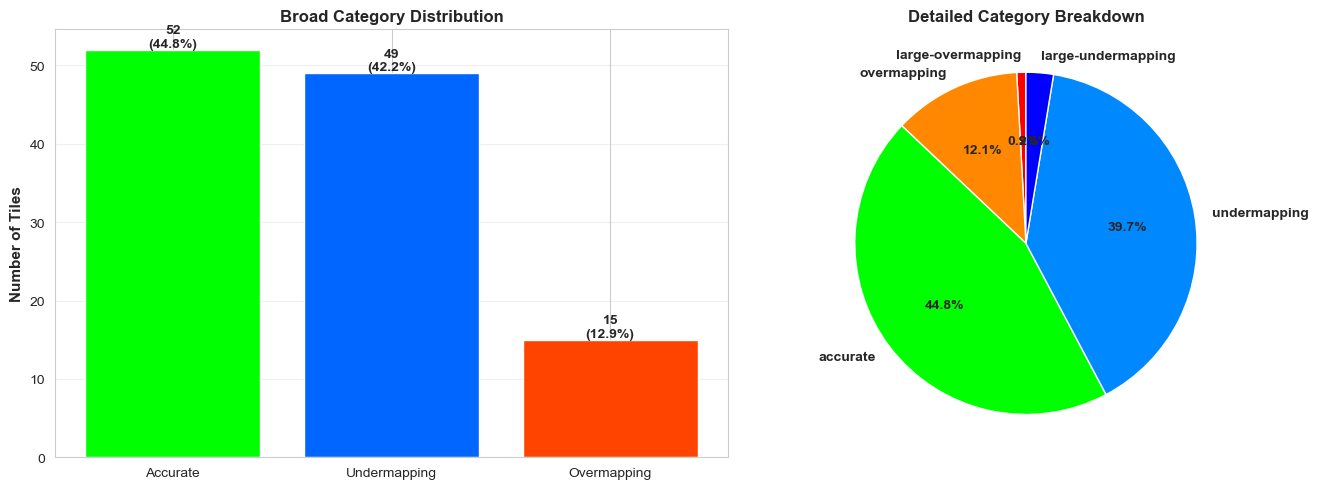


Plot saved to: analysis/broad_category_analysis.png
Location: lombok
BROAD CATEGORY ANALYSIS
broad_category
Overmapping     35
Undermapping    34
Accurate        33
Name: count, dtype: int64

Overmapping    :   35 tiles ( 34.3%)
Undermapping   :   34 tiles ( 33.3%)
Accurate       :   33 tiles ( 32.4%)


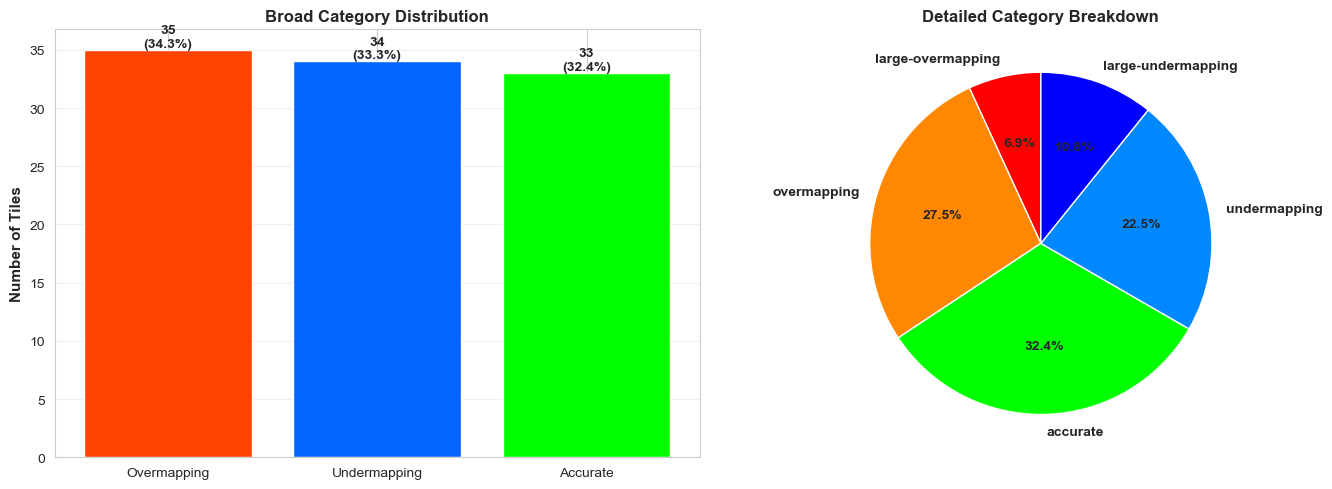


Plot saved to: analysis/broad_category_analysis.png


[None, None, None]

In [78]:
def broad_analysis(df):
    print(f"Location: {df[0]}")
    df = df[1]
    if df is not None and len(df) > 0:
        # Group into broader categories
        def categorize_mapping(label):
            if 'overmapping' in label:
                return 'Overmapping'
            elif 'undermapping' in label:
                return 'Undermapping'
            else:
                return 'Accurate'
        
        df['broad_category'] = df['label'].apply(categorize_mapping)
        
        # Calculate statistics
        broad_counts = df['broad_category'].value_counts()
        
        print("=" * 60)
        print("BROAD CATEGORY ANALYSIS")
        print("=" * 60)
        print(broad_counts)
        print()
        
        # Calculate percentages
        for category, count in broad_counts.items():
            pct = count / len(df) * 100
            print(f"{category:15s}: {count:4d} tiles ({pct:5.1f}%)")
        
        # Create visualization
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        # Bar chart
        colors_broad = {'Overmapping': '#FF4400', 'Accurate': '#00FF00', 'Undermapping': '#0066FF'}
        bars = ax1.bar(range(len(broad_counts)), broad_counts.values,
                       color=[colors_broad.get(cat, '#808080') for cat in broad_counts.index])
        ax1.set_xticks(range(len(broad_counts)))
        ax1.set_xticklabels(broad_counts.index)
        ax1.set_ylabel('Number of Tiles', fontsize=11, fontweight='bold')
        ax1.set_title('Broad Category Distribution', fontsize=12, fontweight='bold')
        ax1.yaxis.grid(True, alpha=0.3)
        
        # Add value labels
        for bar, count in zip(bars, broad_counts.values):
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(count)}\n({count/len(df)*100:.1f}%)',
                    ha='center', va='bottom', fontweight='bold')
        
        # Detailed breakdown within overmapping and undermapping
        detail_data = []
        detail_labels = []
        detail_colors = []
        
        for label in ['large-overmapping', 'overmapping', 'accurate', 'undermapping', 'large-undermapping']:
            count = (df['label'] == label).sum()
            if count > 0:
                detail_data.append(count)
                detail_labels.append(label)
                detail_colors.append(color_map[label])
        
        ax2.pie(detail_data, labels=detail_labels, colors=detail_colors,
                autopct='%1.1f%%', startangle=90,
                textprops={'fontsize': 10, 'fontweight': 'bold'})
        ax2.set_title('Detailed Category Breakdown', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig('../analysis/broad_category_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"\nPlot saved to: analysis/broad_category_analysis.png")
list(map(broad_analysis, dfs))

## 8. Summary Statistics Table

In [80]:
def summary_statistics(df):
    if df is not None and len(df) > 0:
        # Create summary table
        summary_stats = []
        
        for label in ['large-overmapping', 'overmapping', 'accurate', 'undermapping', 'large-undermapping']:
            count = (df['label'] == label).sum()
            percentage = count / len(df) * 100
            
            # Confidence breakdown if available
            if 'confidence' in df.columns:
                label_df = df[df['label'] == label]
                high_conf = (label_df['confidence'] == 'high').sum()
                med_conf = (label_df['confidence'] == 'medium').sum()
                low_conf = (label_df['confidence'] == 'low').sum()
            else:
                high_conf = med_conf = low_conf = 0
            
            summary_stats.append({
                'Label': label,
                'Count': count,
                'Percentage': f"{percentage:.1f}%",
                'High Conf.': high_conf,
                'Med Conf.': med_conf,
                'Low Conf.': low_conf
            })
        
        summary_df = pd.DataFrame(summary_stats)
        
        print("=" * 80)
        print("SUMMARY STATISTICS TABLE")
        print("=" * 80)
        print(summary_df.to_string(index=False))
        print()
        print(f"Total Tiles Labeled: {len(df)}")
        
        # Save to CSV
        summary_df.to_csv('../analysis/summary_statistics.csv', index=False)
        print(f"\nSummary saved to: analysis/summary_statistics.csv")

## 9. Export Data for Further Analysis

In [82]:
def export_data(df):
    if df is not None and len(df) > 0:
        # Create enriched dataset with additional columns
        export_df = df.copy()
        export_df['broad_category'] = export_df['label'].apply(categorize_mapping)
        if 'timestamp' in export_df.columns:
            export_df['datetime'] = pd.to_datetime(export_df['timestamp'], unit='ms')
            export_df['date'] = export_df['datetime'].dt.date
            export_df['hour'] = export_df['datetime'].dt.hour
        
        # Save enriched dataset
        export_df.to_csv('../analysis/enriched_tile_labels.csv', index=False)
        print(f"Enriched dataset saved to: analysis/enriched_tile_labels.csv")
        print(f"Shape: {export_df.shape}")
        print(f"Columns: {export_df.columns.tolist()}")

## 10. Key Findings Summary

In [84]:
def key_findings(df):
    if df is not None and len(df) > 0:
        print("="*80)
        print(" " * 25 + "KEY FINDINGS SUMMARY")
        print("="*80)
        print()
        
        # Most common label
        most_common = df['label'].mode()[0]
        most_common_count = (df['label'] == most_common).sum()
        print(f"1. Most Common Label: {most_common} ({most_common_count} tiles, {most_common_count/len(df)*100:.1f}%)")
        
        # Least common label
        least_common = df['label'].value_counts().idxmin()
        least_common_count = (df['label'] == least_common).sum()
        print(f"2. Least Common Label: {least_common} ({least_common_count} tiles, {least_common_count/len(df)*100:.1f}%)")
        
        # Overmapping vs Undermapping
        overmapping_count = df['broad_category'].eq('Overmapping').sum()
        undermapping_count = df['broad_category'].eq('Undermapping').sum()
        accurate_count = df['broad_category'].eq('Accurate').sum()
        
        print(f"3. Overmapping: {overmapping_count} tiles ({overmapping_count/len(df)*100:.1f}%)")
        print(f"4. Undermapping: {undermapping_count} tiles ({undermapping_count/len(df)*100:.1f}%)")
        print(f"5. Accurate: {accurate_count} tiles ({accurate_count/len(df)*100:.1f}%)")
        
        # Confidence
        if 'confidence' in df.columns:
            high_conf = (df['confidence'] == 'high').sum()
            print(f"6. High Confidence Labels: {high_conf} ({high_conf/len(df)*100:.1f}%)")
        
        # Mapping quality assessment
        print()
        print("7. Overall Mapping Quality Assessment:")
        if accurate_count / len(df) > 0.6:
            print("   → HIGH QUALITY: Most tiles show accurate mapping")
        elif accurate_count / len(df) > 0.4:
            print("   → MODERATE QUALITY: Mixed mapping accuracy")
        else:
            print("   → NEEDS IMPROVEMENT: Significant mapping errors detected")
        
        if overmapping_count > undermapping_count * 1.5:
            print("   → SYSTEMATIC OVERMAPPING DETECTED")
        elif undermapping_count > overmapping_count * 1.5:
            print("   → SYSTEMATIC UNDERMAPPING DETECTED")
        else:
            print("   → BALANCED ERROR DISTRIBUTION")
        
        print()
        print("="*80)
    else:
        print("No data available for analysis.")